In [1]:
import pandas as pd
import numpy as np
from final_project.data import read_data
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from collections import OrderedDict
from torch.utils.data import DataLoader, TensorDataset
import scipy.stats as stats
import itertools


/opt/homebrew/Caskroom/miniconda/base/envs/final-project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data

In [2]:
df = read_data("btc_with_gbt_preds")
df.head()

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,quote_volume_pct_change,past_180m_vol,past_720m_vol,past_1440m_vol,past_10080m_vol,past_43200m_vol,past_50m_span_ewm_vol,past_50m_vol_pct_change,event_code,gbt_future_30m_mean_sq_ret_pred
43200,train,2023-11-30 19:00:00 ET,37723.97,37744.72,37722.73,37738.91,34.53633,2023-11-30 19:00:59 ET,1.303099e+06,1119,...,0.061855,0.175818,0.277380,0.260482,0.320534,0.412684,0.185884,-0.099284,NONE,9.346555e-08
43201,train,2023-11-30 19:01:00 ET,37738.91,37738.91,37723.72,37723.72,12.71120,2023-11-30 19:01:59 ET,4.796356e+05,667,...,0.096078,0.176291,0.277533,0.260587,0.320546,0.412684,0.190869,-0.081458,NONE,9.226979e-08
43202,train,2023-11-30 19:02:00 ET,37723.72,37723.73,37699.57,37699.57,33.22694,2023-11-30 19:02:59 ET,1.252938e+06,956,...,0.012599,0.177571,0.277139,0.260694,0.320557,0.412678,0.195810,-0.067271,NONE,9.546778e-08
43203,train,2023-11-30 19:03:00 ET,37699.58,37699.58,37699.57,37699.57,6.89939,2023-11-30 19:03:59 ET,2.601041e+05,341,...,0.093164,0.180828,0.277650,0.260867,0.320590,0.412682,0.212787,-0.013871,NONE,1.121719e-07
43204,train,2023-11-30 19:04:00 ET,37699.57,37699.58,37688.27,37688.35,14.22495,2023-11-30 19:04:59 ET,5.362203e+05,476,...,-0.004551,0.179834,0.276626,0.260862,0.320585,0.412672,0.208573,-0.042709,NONE,9.886201e-08


Note that data is pre-split into train/val/test, and we already have predictions from my best GBT model. Plenty of preprocessing has already been done.

### Part 2: Mixed Density Network
Now, I will construct a feature set and training/validation pipeline to create the best MDN to predict future distributions of returns.

In [3]:
df_train = df.query("split == 'train'")

In [4]:
def downsample(df: pd.DataFrame, minutes: set[int]) -> pd.DataFrame:
    """
    Return dataframe with datapoints from specified minutes within each hour.
    """
    return df[df["minute"].isin(minutes)]

def add_past_returns(df: pd.DataFrame, windows: list[int], log: bool = False) -> pd.DataFrame:
    """
    Return dataframe with past returns computed for each window (in minutes). 
    Assumes data is every minute.
    """
    df = df.copy()
    for window in windows:
        ret = df["open"] / df["open"].shift(window) - 1
        df[f"past_{window}m_{'log_' if log else ''}ret"] = np.log(1 + ret) if log else ret
    return df

def add_past_mean_sq_returns(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with past mean 1m sq returns for each window (in minutes). 
    Assumes data is every minute.
    """
    df = df.copy()
    ret = df["open"] / df["open"].shift(1) - 1
    df["past_1m_sq_ret"] = ret ** 2
    
    for window in windows:
        df[f"past_{window}m_mean_sq_ret"] = df["past_1m_sq_ret"].rolling(window).mean()
    
    return df

def add_normalized_past_returns(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with past returns normalized by mean 1m sq returns over that period.
    for each window. Assumes data is every minute.
    """
    df = df.copy()
    df = add_past_returns(df, windows=windows)
    df = add_past_mean_sq_returns(df, windows=windows)
    for window in windows:
        df[f"past_{window}m_norm_ret"] = df[f"past_{window}m_ret"] / np.sqrt(df[f"past_{window}m_mean_sq_ret"] * window)
    return df

def add_future_returns(df: pd.DataFrame, windows: list[int], log: bool = False) -> pd.DataFrame:
    """
    Return dataframe with future returns for each window. Assumes data is every minute.
    """
    df = df.copy()
    for window in windows:
        ret = df["open"].shift(-window) / df["open"] - 1
        df[f"future_{window}m_{'log_' if log else ''}ret"] = np.log(1 + ret) if log else ret
    return df


def add_lagged_returns(df: pd.DataFrame, window:int, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with past returns normalized by mean 1m sq returns over that period.
    for each window. Assumes data is every minute.
    """
    df = df.copy()
    df = add_past_returns(df, windows=windows)
    df = add_past_mean_sq_returns(df, windows=windows)
    for window in windows:
        df[f"past_{window}m_norm_ret"] = df[f"past_{window}m_ret"] / np.sqrt(df[f"past_{window}m_mean_sq_ret"] * window)
    return df

In [5]:
df = add_future_returns(df, [30])
df = add_past_returns(df, [30])

In [6]:
NUM_FEATURES = [
    "past_1m_ret",
    "past_5m_ret",
    "past_30m_ret",
    "past_60m_ret",
    "past_120m_ret",
    "past_1m_sq_ret",
    "past_5m_sq_ret",
    "past_30m_sq_ret",
    "past_60m_sq_ret",
    "past_120m_sq_ret",
    "past_1440m_vol",
    "past_10080m_vol",
    "past_43200m_vol",
    "past_50m_span_ewm_vol",
    "past_50m_vol_pct_change",
    "past_30m_quote_volume",
    "past_30m_trades",
    "quote_volume_pct_change",
    "is_us_trading_day",
    "is_eu_trading_day",
    "is_uk_trading_day",
    "is_jp_trading_day",
    "is_cn_trading_day",
    "is_hk_trading_day",
    "is_us_dst",
    "is_eu_dst",
    "gbt_future_30m_mean_sq_ret_pred"
]

CAT_FEATURES = ["time_of_day", "event_code"]

TARGET_COL = "future_30m_ret"




df_train = downsample(df.query("split == 'train'"), set([0, 30])).dropna()
df_val = downsample(df.query("split == 'val'"), set([0, 30])).dropna()

# Make numerical feature tensors
X_train_num = df_train[NUM_FEATURES].to_numpy(dtype=np.float32)
X_val_num = df_val[NUM_FEATURES].to_numpy(dtype=np.float32)
y_train = df_train[TARGET_COL].to_numpy(dtype=np.float32)
y_val = df_val[TARGET_COL].to_numpy(dtype=np.float32)

# Scale features, train scaler on train set
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num)

X_train_num = torch.tensor(X_train_num, dtype=torch.float32)
X_val_num = torch.tensor(X_val_num, dtype=torch.float32)

# Make categorical feature tensors
X_train_cat = df_train[CAT_FEATURES]
X_val_cat = df_val[CAT_FEATURES]

# Encode categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown="error")
X_train_cat = encoder.fit_transform(X_train_cat)
X_val_cat = encoder.transform(X_val_cat)

X_train_cat = torch.tensor(X_train_cat, dtype=torch.float32)
X_val_cat = torch.tensor(X_val_cat, dtype=torch.float32)

X_train = torch.cat([X_train_num, X_train_cat], dim=1)
X_val = torch.cat([X_val_num, X_val_cat], dim=1)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)




device = "cuda" if torch.cuda.is_available() else "cpu"



First model: hidden layers directly to output layer for mixed density parameters.

In [7]:
# Create MDN

class MDN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, hidden_layers=2, n_components=3, mean_zero=False):
        super().__init__()

        hidden_layer_list = []
        for i in range(hidden_layers):
            hidden_layer_list.append((f"linear{i}", nn.Linear(hidden_dim, hidden_dim)))
            hidden_layer_list.append((f"relu{i+1}", nn.ReLU()))


        self.net = nn.Sequential(OrderedDict([
            ("input", nn.Linear(input_dim, hidden_dim)),
            ("relu1", nn.ReLU())] + hidden_layer_list
        ))

        self.mixture_weights = nn.Linear(hidden_dim, n_components)
        if not mean_zero:
            self.means = nn.Linear(hidden_dim, n_components)
        else:
            self.means = None
        self.scales = nn.Linear(hidden_dim, n_components)

        self.n_components = n_components

    def forward(self, x):
        out = self.net(x)

        mixture_weights = self.mixture_weights(out)

        if self.means is not None:
            means = self.means(out)
        else:
            means = torch.zeros(out.shape[0], self.n_components, device=out.device)

        scales = F.softplus(self.scales(out)) + 1e-6

        return mixture_weights, means, scales


def compute_nll_from_output(y, mixture_weights, means, scales):
    y = y.unsqueeze(1)

    log_probs = (
        -0.5 * np.log(2 * np.pi)
        - torch.log(scales)
        - 0.5 * ((y - means) / scales) ** 2
    )

    log_mix = F.log_softmax(mixture_weights, dim=1)
    log_density = torch.logsumexp(log_mix + log_probs, dim=1)

    return -log_density.mean()

def compute_nll(model, data_loader):
    model.eval() 
    size = 0
    nll_sum = 0
    with torch.no_grad():
        for (X, y) in data_loader:
            X, y = X.to(device), y.to(device)
            mixture_weights, means, scales = model(X)

            nll = compute_nll_from_output(y, mixture_weights, means, scales)
            nll_sum += nll * X.size(0)
            size += X.size(0)

    return nll_sum / size

def crps_helper(a, scale):
    """
    Closed form function used for gaussian mixture CRPS.
    """
    value = 2 * scale * stats.norm.pdf(a / scale) +  a * (2 * stats.norm.cdf(a / scale) - 1)
    return value

def compute_crps(model, data_loader):
    """
    Compute mean crps using MDN and data loader.
    """
    model.eval() 
    all_crps = []
    with torch.no_grad():
        for (X, y) in data_loader:
            X, y = X.to(device), y.to(device)
            mixture_weights, means, scales = model(X)
            mixture_probs = F.softmax(mixture_weights, dim=1)

            a_one = y.unsqueeze(1) - means
            scale_one = scales
            weights_one = mixture_probs
            first_term_raw = crps_helper(a_one, scale_one)
            first_term = torch.sum(first_term_raw * weights_one, dim=1)
            
            a_two = means.unsqueeze(2) - means.unsqueeze(1)
            scale_two = torch.sqrt(scales.unsqueeze(2) ** 2 + scales.unsqueeze(1) ** 2)
            weights_two = mixture_probs.unsqueeze(2) * mixture_probs.unsqueeze(1)
            second_term_raw = crps_helper(a_two, scale_two)
            second_term = torch.sum(second_term_raw * weights_two, dim=(1, 2))

            crpss = first_term - 0.5 * second_term
            all_crps.append(crpss)

    crps_tensor = torch.concat(all_crps, dim=0)

    return torch.mean(crps_tensor).item()

In [8]:
# Function to train MDN
def train(
    model,
    data_loader,
    optimizer,
):
    model = model.to(device)

    model.train()
    nlls = []


    for _, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        mixture_weights, means, scales = model(X)

        loss = compute_nll_from_output(y, mixture_weights, means, scales)
        nlls.append(loss.item())

        loss.backward()
        optimizer.step()
    
    return np.mean(nlls)

def get_predicted_parameters(model, data_loader):
    """
    Return predicted mixture weights, means, and scales across dataset.
    """
    model.eval() 
    weights = []
    means = []
    scales = []
    with torch.no_grad():
        for (X, y) in data_loader:
            X, y = X.to(device), y.to(device)
            mixture_weight, mean, scale = model(X)
            mixture_probs = F.softmax(mixture_weight, dim=1)
            weights.append(mixture_probs)
            means.append(mean)
            scales.append(scale)

        weights = torch.cat(weights, dim=0)
        means = torch.cat(means, dim=0)
        scales = torch.cat(scales, dim=0)

    return weights, means, scales

In [23]:
# Convert data to dataloader
param_grid = {
    "batch_size": [256],
    "hidden_dim": [16],
    "hidden_layers": [3],
    "n_components": [3, 4, 5],
    "mean_zero": [True],
    "lr": [1e-4]
}

all_results = {}
keys = param_grid.keys()
values = param_grid.values()
i = 0
n = len(list(itertools.product(*values)))

param_list = []
best_val_nll_list = []
avg_val_nll_last_20_list = []
avg_train_nll_last_20_list = []
avg_val_crps_last_20_list = []

for combo in itertools.product(*values):

    params = dict(zip(keys, combo))
    print(f"testing {params}, {i+1}/{n}")

    train_data = TensorDataset(X_train, y_train)
    val_data = TensorDataset(X_val, y_val)

    train_loader = DataLoader(train_data, batch_size=params["batch_size"], shuffle=True)
    val_loader = DataLoader(val_data, batch_size=params["batch_size"], shuffle=False)

    model = MDN(
        input_dim=X_train.shape[1],
        hidden_dim=params["hidden_dim"],
        hidden_layers=params["hidden_layers"],
        n_components=params["n_components"],
        mean_zero=params["mean_zero"]
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])

    epochs = 200
    results = []
    best_val_nll = np.inf
    last_improvement = 0
    for t in range(epochs):
        epoch_loss = train(model, train_loader, optimizer)
        epoch_val_nll = compute_nll(model, val_loader)
        epoch_train_nll = compute_nll(model, train_loader)
        epoch_val_crps = compute_crps(model, val_loader)

        if epoch_val_nll < best_val_nll:
            best_val_nll = epoch_val_nll
            last_improvement = t

        # if t % 20 == 19:
        #     print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_accuracy:.2f}, val nll: {epoch_test_accuracy:.2f}")
        results.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
        
        if t - last_improvement >= 20:
            break

    results = np.array(results)

    val_nlls = results[:, 2]
    train_nlls = results[:, 1]
    val_crpss = results[:, 3]

    avg_val_nll_last_20 = np.mean(val_nlls[-20:])
    avg_train_nll_last_20 = np.mean(train_nlls[-20:])
    avg_val_crps_last_20 = np.mean(val_crpss[-20:])

    param_key = tuple(sorted(params.items()))

    param_list.append(param_key)
    best_val_nll_list.append(best_val_nll)
    avg_val_nll_last_20_list.append(avg_val_nll_last_20)
    avg_train_nll_last_20_list.append(avg_train_nll_last_20)
    avg_val_crps_last_20_list.append(avg_val_crps_last_20)

    print(f"Best Val NLL: {best_val_nll}, took {len(results)} epochs")
    i += 1

df_results = pd.DataFrame({"params": param_list, "best_val_nll": best_val_nll_list, "avg_val_nll_last_20": avg_val_nll_last_20_list,
                           "avg_train_nll_last_20": avg_train_nll_last_20_list, "avg_val_crps_last_20": avg_val_crps_last_20_list})


testing {'batch_size': 256, 'hidden_dim': 16, 'hidden_layers': 3, 'n_components': 3, 'mean_zero': True, 'lr': 0.0001}, 1/3
Best Val NLL: -4.5572590827941895, took 168 epochs
testing {'batch_size': 256, 'hidden_dim': 16, 'hidden_layers': 3, 'n_components': 4, 'mean_zero': True, 'lr': 0.0001}, 2/3
Best Val NLL: -4.5560150146484375, took 140 epochs
testing {'batch_size': 256, 'hidden_dim': 16, 'hidden_layers': 3, 'n_components': 5, 'mean_zero': True, 'lr': 0.0001}, 3/3
Best Val NLL: -4.560136795043945, took 156 epochs


In [25]:
pd.set_option("display.max_colwidth", None)
df_results.sort_values(by="best_val_nll")

,params,best_val_nll,avg_val_nll_last_20,avg_train_nll_last_20,avg_val_crps_last_20
2,"((batch_size, 256), (hidden_dim, 16), (hidden_layers, 3), (lr, 0.0001), (mean_zero, True), (n_components, 5))",tensor(-4.5601),-4.559390,-4.413362,0.001619
0,"((batch_size, 256), (hidden_dim, 16), (hidden_layers, 3), (lr, 0.0001), (mean_zero, True), (n_components, 3))",tensor(-4.5573),-4.556813,-4.414001,0.001620
1,"((batch_size, 256), (hidden_dim, 16), (hidden_layers, 3), (lr, 0.0001), (mean_zero, True), (n_components, 4))",tensor(-4.5560),-4.554963,-4.412097,0.001623


Did plenty of grid search: shallow nets 3-4 deep performed best. Settled on component selection for 3x16, 5 components performed best.

In [ ]:

print(f"testing {params}, {i+1}/{n}")

train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=params["batch_size"], shuffle=True)
val_loader = DataLoader(val_data, batch_size=params["batch_size"], shuffle=False)

model = MDN(
    input_dim=X_train.shape[1],
    hidden_dim=params["hidden_dim"],
    hidden_layers=params["hidden_layers"],
    n_components=params["n_components"],
    mean_zero=params["mean_zero"]
)

optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])

epochs = 200
results = []
best_val_nll = np.inf
last_improvement = 0
for t in range(epochs):
    epoch_loss = train(model, train_loader, optimizer)
    epoch_val_nll = compute_nll(model, val_loader)
    epoch_train_nll = compute_nll(model, train_loader)
    epoch_val_crps = compute_crps(model, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t

    # if t % 20 == 19:
    #     print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_accuracy:.2f}, val nll: {epoch_test_accuracy:.2f}")
    results.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= 20:
        break

results = np.array(results)


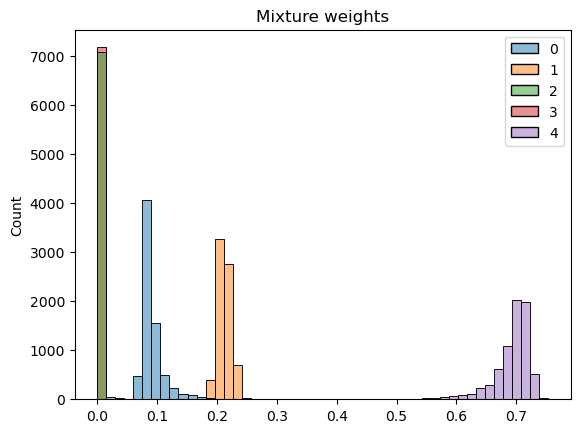

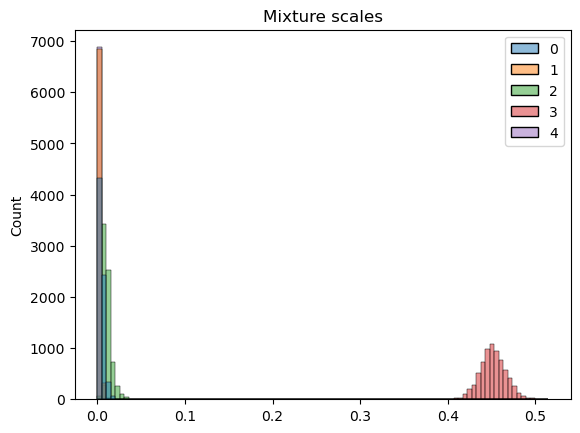

In [142]:
val_weights, val_means, val_scales = (p.numpy() for p in get_predicted_parameters(model, val_loader))
ax = sns.histplot(val_weights, bins=50)
ax.set_title("Mixture weights")
plt.show()

# ax = sns.histplot(val_means, bins=50)
# ax.set_title("Mixture means")
# # plt.show()

ax = sns.histplot(val_scales, bins=100)
ax.set_title("Mixture scales")
plt.show()

###